<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/10_Model_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 10: Model Interpretation**

Understand the relationship between the dataset features and the target
variable and investigate which features are most strongly associated with
heart disease predictions.

Analysis:
1. Feature-target relationships
2. Correlation analysis
3. Feature distribution by target
4. Permutation importance
5. Interpretation of the selected KNN model

The goal is to understand model behavior rather than only reporting
prediction performance.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## **Path Setting**

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction"

DATASET_PATH = PROJECT_PATH + "/Dataset"
RESULT_PATH = PROJECT_PATH + "/Results"
MODEL_PATH = PROJECT_PATH + "/Models"

# **Load and Clean Dataset**

In [ ]:
df = pd.read_csv(DATASET_PATH + "/heart.csv")
#df = pd.read_csv(DATASET_PATH + "/heart.csv")

df_clean = df.drop_duplicates().copy()

print("Original: ", df.shape)
print("Cleaned: ", df_clean.shape)

Original:  (1025, 14)
Cleaned:  (302, 14)


## **Inspect Featues**

In [ ]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df_clean.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# **Separate X and y**

In [ ]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

In [ ]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


## Feature Description

| Feature | Meaning |
|---|---|
| age | Age of the patient |
| sex | Sex |
| cp | Chest pain type |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol |
| fbs | Fasting blood sugar |
| restecg | Resting electrocardiographic result |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels |
| thal | Thalassemia-related measurement |
| target | Heart disease class |

The target is binary:
- 0 = No heart disease
- 1 = Heart disease

# **Corealtion Matrix**

In [ ]:
correlation = df_clean.corr(numeric_only=True)
correlation.round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.00,-0.09,-0.06,0.28,0.21,0.12,-0.11,-0.40,0.09,0.21,-0.16,0.30,0.07,-0.22
sex,-0.09,1.00,-0.05,-0.06,-0.20,0.05,-0.06,-0.05,0.14,0.10,-0.03,0.11,0.21,-0.28
cp,-0.06,-0.05,1.00,0.05,-0.07,0.10,0.04,0.29,-0.39,-0.15,0.12,-0.20,-0.16,0.43
trestbps,0.28,-0.06,0.05,1.00,0.13,0.18,-0.12,-0.05,0.07,0.19,-0.12,0.10,0.06,-0.15
chol,0.21,-0.20,-0.07,0.13,1.00,0.01,-0.15,-0.01,0.06,0.05,0.00,0.09,0.10,-0.08
fbs,0.12,0.05,0.10,0.18,0.01,1.00,-0.08,-0.01,0.02,0.00,-0.06,0.14,-0.03,-0.03
restecg,-0.11,-0.06,0.04,-0.12,-0.15,-0.08,1.00,0.04,-0.07,-0.06,0.09,-0.08,-0.01,0.13
thalach,-0.40,-0.05,0.29,-0.05,-0.01,-0.01,0.04,1.00,-0.38,-0.34,0.38,-0.23,-0.09,0.42
exang,0.09,0.14,-0.39,0.07,0.06,0.02,-0.07,-0.38,1.00,0.29,-0.26,0.13,0.21,-0.44
oldpeak,0.21,0.10,-0.15,0.19,0.05,0.00,-0.06,-0.34,0.29,1.00,-0.58,0.24,0.21,-0.43


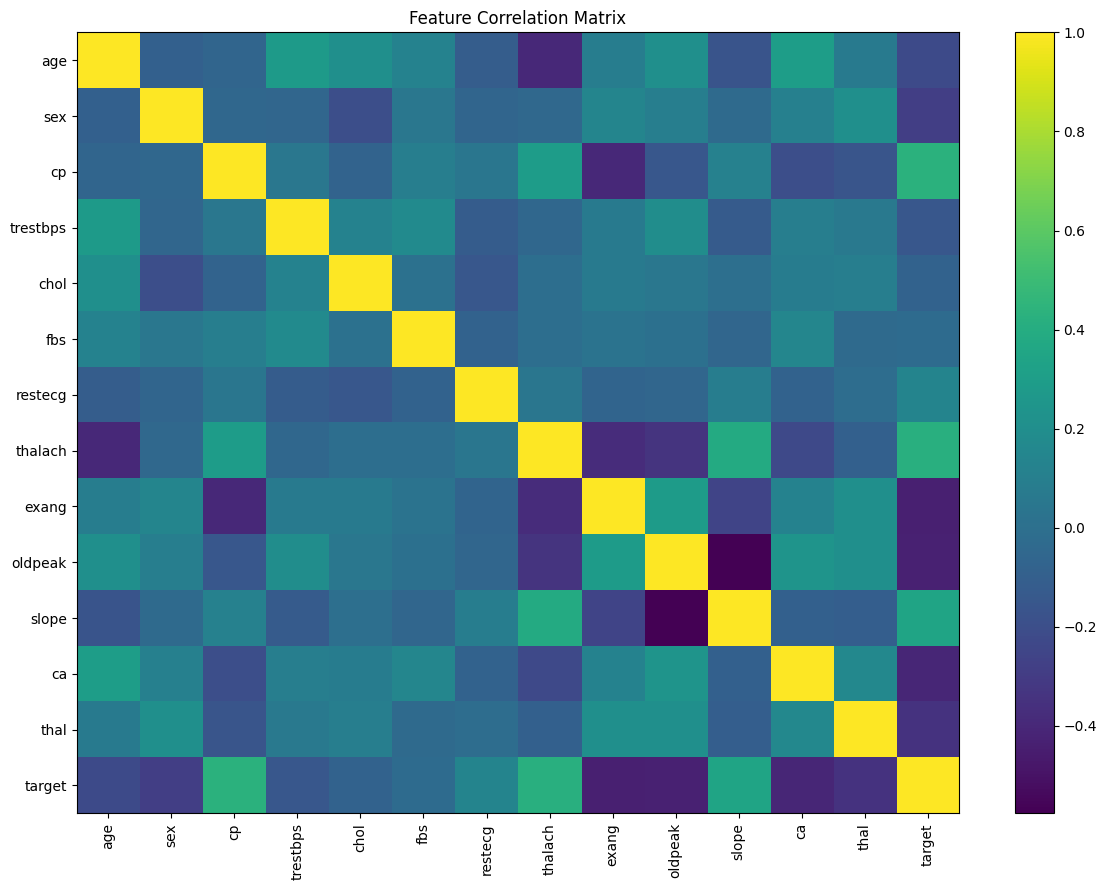

In [ ]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

# **Correlation with Target**

In [ ]:
target_correlation = (
    correlation["target"]
    .drop("target")
    .sort_values()
)

target_correlation

,target
exang,-0.435601
oldpeak,-0.429146
ca,-0.408992
thal,-0.343101
sex,-0.283609
age,-0.221476
trestbps,-0.146269
chol,-0.081437
fbs,-0.026826
restecg,0.134874


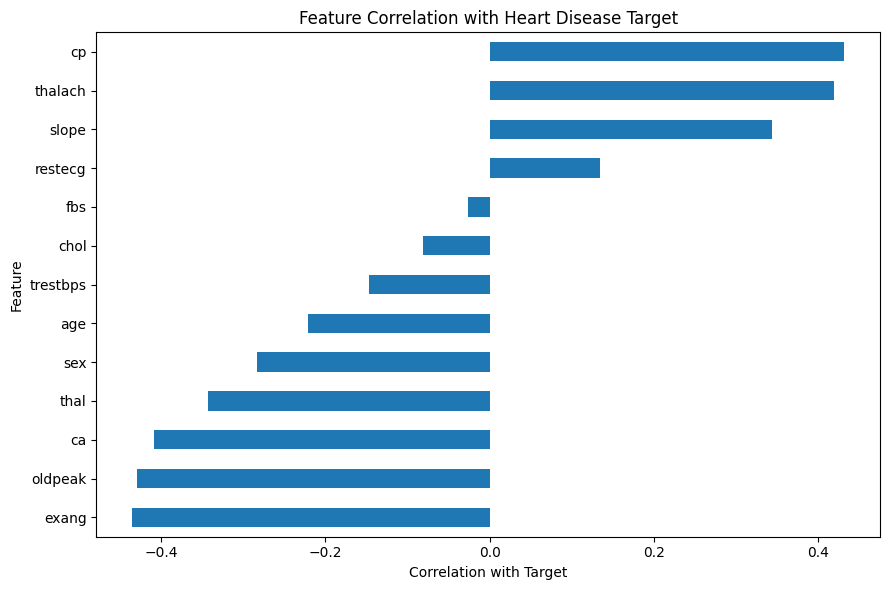

In [ ]:
plt.figure(figsize=(9, 6))

target_correlation.plot(
    kind="barh"
)

plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.title("Feature Correlation with Heart Disease Target")

plt.tight_layout()
plt.show()

# **Target Distribution by Features**

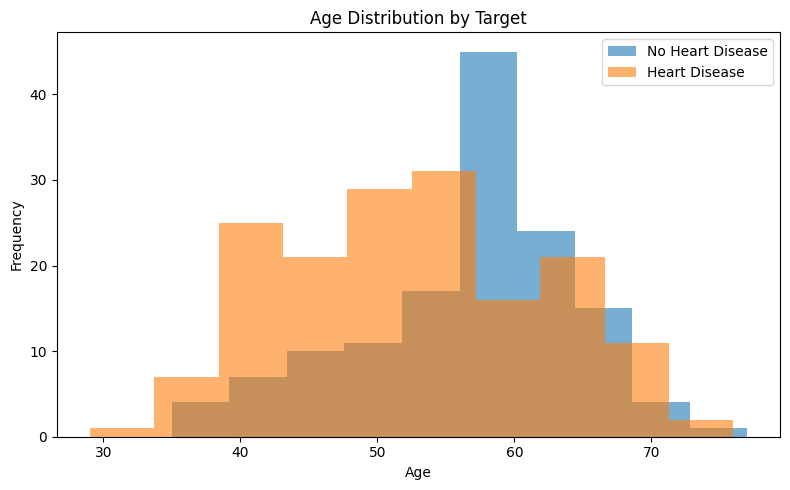

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean[df_clean["target"] == 0]["age"],
    alpha=0.6,
    label="No Heart Disease"
)

plt.hist(
    df_clean[df_clean["target"] == 1]["age"],
    alpha=0.6,
    label="Heart Disease"
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution by Target")
plt.legend()

plt.tight_layout()
plt.show()

## **Maximum Heart Rate**

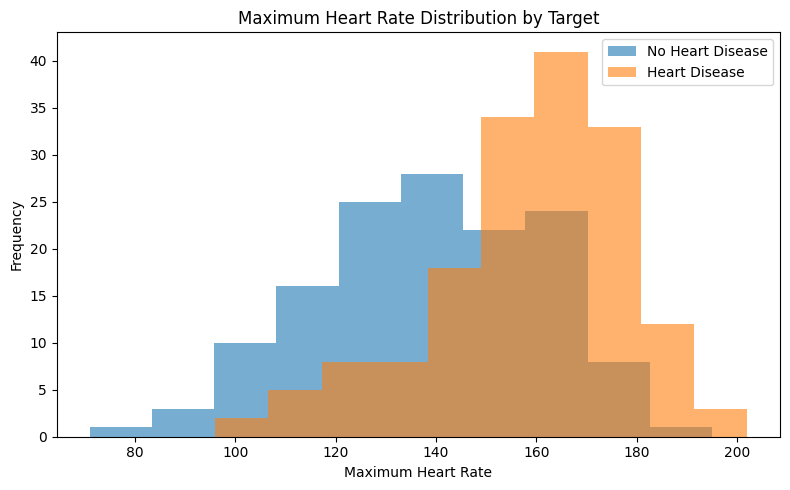

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean[df_clean["target"] == 0]["thalach"],
    alpha=0.6,
    label="No Heart Disease"
)

plt.hist(
    df_clean[df_clean["target"] == 1]["thalach"],
    alpha=0.6,
    label="Heart Disease"
)

plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")
plt.title("Maximum Heart Rate Distribution by Target")
plt.legend()

plt.tight_layout()
plt.show()

## **Old Peak**

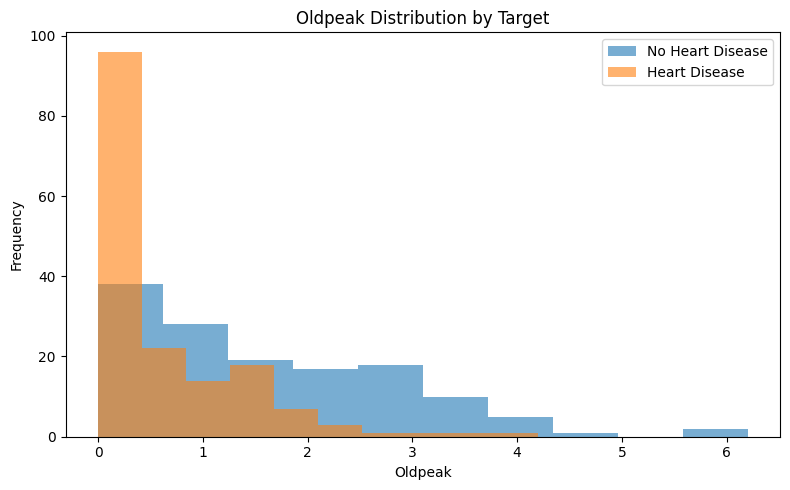

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean[df_clean["target"] == 0]["oldpeak"],
    alpha=0.6,
    label="No Heart Disease"
)

plt.hist(
    df_clean[df_clean["target"] == 1]["oldpeak"],
    alpha=0.6,
    label="Heart Disease"
)

plt.xlabel("Oldpeak")
plt.ylabel("Frequency")
plt.title("Oldpeak Distribution by Target")
plt.legend()

plt.tight_layout()
plt.show()

## **Chest Pain Type**

In [ ]:
cp_target = pd.crosstab(
    df_clean["cp"],
    df_clean["target"],
    normalize="index"
)

cp_target

target,0,1
cp,,
0,0.727273,0.272727
1,0.180000,0.820000
2,0.209302,0.790698
3,0.304348,0.695652


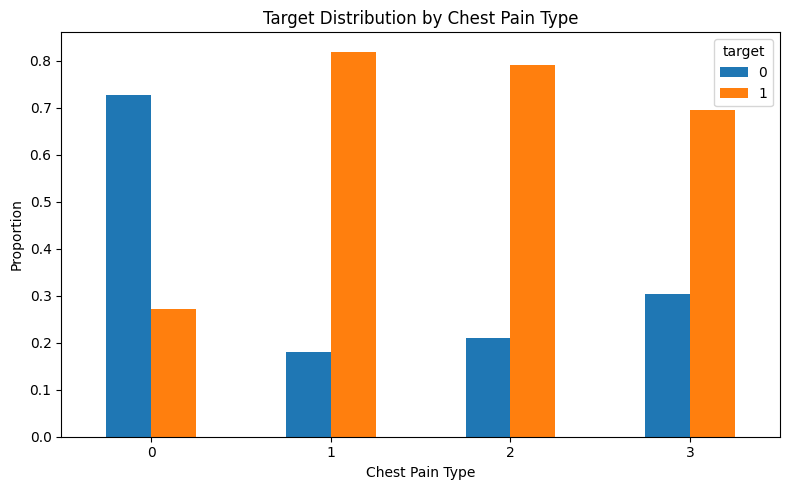

In [ ]:
cp_target.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Chest Pain Type")
plt.ylabel("Proportion")
plt.title("Target Distribution by Chest Pain Type")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## **Exercise Included Angina**

In [ ]:
exang_target = pd.crosstab(
    df_clean["exang"],
    df_clean["target"],
    normalize="index"
)

exang_target

target,0,1
exang,,
0,0.305419,0.694581
1,0.767677,0.232323


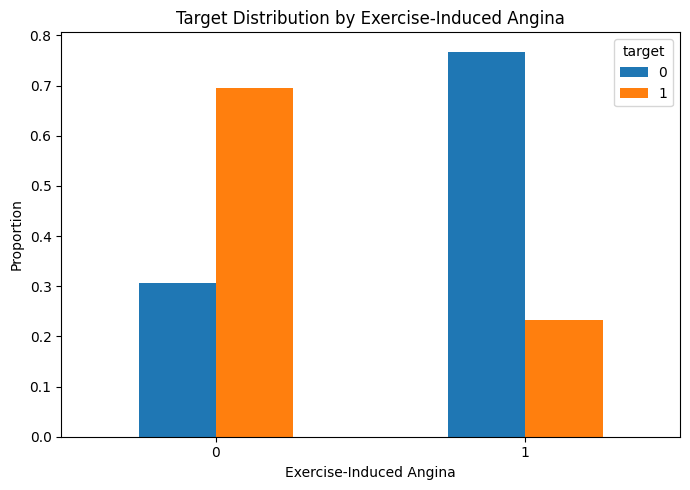

In [ ]:
exang_target.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Proportion")
plt.title("Target Distribution by Exercise-Induced Angina")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# **KNN Interpretations**

## **Train / Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(241, 13)
(241,)


# **Load Final KNN Model**

In [ ]:
final_model = joblib.load(
    MODEL_PATH + "/final_heart_disease_model.pkl"
)

In [ ]:
print(final_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=21, p=1))])


# **Permutation Importance**

In [ ]:
result = permutation_importance(
    final_model,
    X_train,
    y_train,
    n_repeats=20,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

# **Importance Data Frame**

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
})

importance_df = importance_df.sort_values(
    "Importance Mean",
    ascending=False
).reset_index(drop=True)

importance_df.round(4)

,Feature,Importance Mean,Importance Std
0,cp,0.0216,0.0101
1,thal,0.0206,0.0077
2,ca,0.0190,0.0084
3,sex,0.0150,0.0082
4,exang,0.0140,0.0087
5,slope,0.0084,0.0057
6,oldpeak,0.0081,0.0087
7,restecg,0.0075,0.0055
8,age,0.0017,0.0072
9,fbs,0.0013,0.0045


## **Feature Importance Visualize**

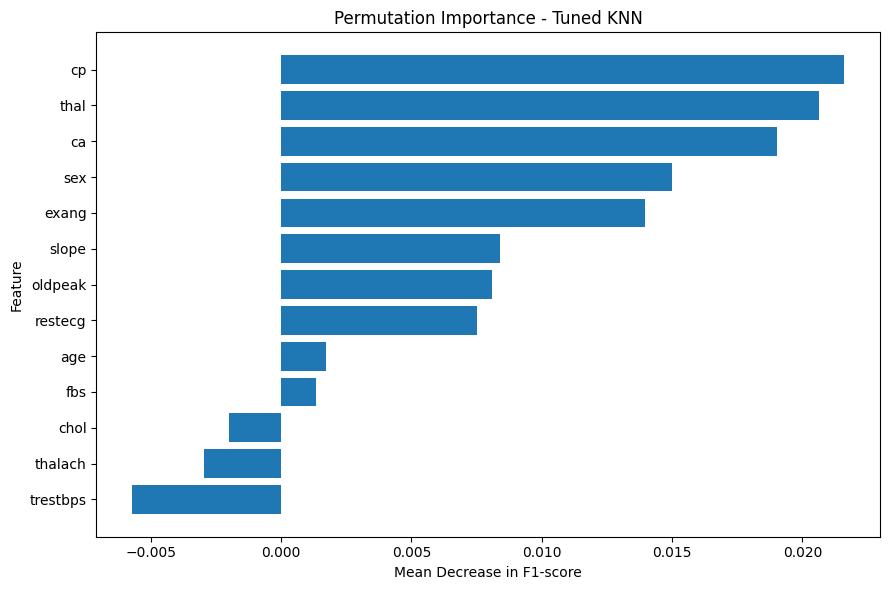

In [ ]:
plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance Mean"]
)

plt.xlabel("Mean Decrease in F1-score")
plt.ylabel("Feature")
plt.title("Permutation Importance - Tuned KNN")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
importance_df.to_csv(
    RESULT_PATH + "/knn_permutation_importance.csv",
    index=False
)

# **Correlation Vs Permutation**

In [ ]:
interpretation_df = importance_df.copy()

interpretation_df["Correlation"] = (
    interpretation_df["Feature"]
    .map(target_correlation)
)

interpretation_df.round(4)

,Feature,Importance Mean,Importance Std,Correlation
0,cp,0.0216,0.0101,0.4321
1,thal,0.0206,0.0077,-0.3431
2,ca,0.0190,0.0084,-0.4090
3,sex,0.0150,0.0082,-0.2836
4,exang,0.0140,0.0087,-0.4356
5,slope,0.0084,0.0057,0.3439
6,oldpeak,0.0081,0.0087,-0.4291
7,restecg,0.0075,0.0055,0.1349
8,age,0.0017,0.0072,-0.2215
9,fbs,0.0013,0.0045,-0.0268


# **Permutation Importance with ROC_AUC**

In [ ]:
roc_importance = permutation_importance(
    final_model,
    X_train,
    y_train,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

roc_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": roc_importance.importances_mean,
    "Importance Std": roc_importance.importances_std
})

roc_importance_df = roc_importance_df.sort_values(
    "Importance Mean",
    ascending=False
).reset_index(drop=True)

roc_importance_df.round(4)

,Feature,Importance Mean,Importance Std
0,thal,0.0256,0.0094
1,sex,0.0217,0.0079
2,ca,0.0187,0.0056
3,cp,0.0179,0.0047
4,exang,0.0067,0.0063
5,restecg,0.0056,0.0027
6,oldpeak,0.0042,0.0041
7,age,0.0029,0.0031
8,slope,0.0019,0.0042
9,thalach,0.0009,0.0035


# **Interpretation Table**

In [ ]:
importance_comparison = importance_df[
    ["Feature", "Importance Mean"]
].rename(
    columns={"Importance Mean": "F1 Importance"}
)

importance_comparison = importance_comparison.merge(
    roc_importance_df[
        ["Feature", "Importance Mean"]
    ].rename(
        columns={"Importance Mean": "ROC-AUC Importance"}
    ),
    on="Feature"
)

importance_comparison = importance_comparison.sort_values(
    "F1 Importance",
    ascending=False
)

importance_comparison.round(4)

,Feature,F1 Importance,ROC-AUC Importance
0,cp,0.0216,0.0179
1,thal,0.0206,0.0256
2,ca,0.0190,0.0187
3,sex,0.0150,0.0217
4,exang,0.0140,0.0067
5,slope,0.0084,0.0019
6,oldpeak,0.0081,0.0042
7,restecg,0.0075,0.0056
8,age,0.0017,0.0029
9,fbs,0.0013,-0.0018


In [ ]:
importance_comparison.to_csv(
    RESULT_PATH + "/feature_importance_comparison.csv",
    index=False
)

# **Conclusion**

**Model Interpretation Conclusion**

Permutation importance was calculated using two evaluation metrics:
F1-score and ROC-AUC.

The F1-based analysis identified `cp`, `thal`, `ca`, `sex`, and `exang`
as the five highest-ranked features.

The ROC-AUC-based analysis identified `thal`, `sex`, `ca`, `cp`, and
`exang` among the most influential features.

Across both analyses, `thal`, `ca`, `cp`, and `sex` consistently showed
relatively high permutation importance. This suggests that the trained
KNN model relied substantially on information contained in these features
when making predictions.

The exact ranking changed depending on the evaluation metric. This
demonstrates that feature importance is dependent on how model performance
is measured.

Features such as `fbs`, `chol`, `thalach`, and `trestbps` showed very small
or slightly negative permutation importance values in these experiments.
These values do not indicate negative medical effects. Rather, they mean
that randomly permuting those features did not produce a consistent
decrease in the selected model's performance.

The analysis describes the behavior of this specific trained KNN model
on this dataset. It does not establish causal relationships and should
not be interpreted as clinical evidence.